In [1]:
# Imports
import ROOT
import array

from tools import scale_out as so
from tools import storage as stor

from emm import data
from emm import fitting
from emm import models
from emm import plotting

import matplotlib.pyplot as plt
import numpy as np

figures_cache = stor.ensure_cache("figures")

Welcome to JupyROOT 6.30/04


# ATLAS

https://www.hepdata.net/record/ins1759712

In [2]:
# Load the data
h_obs, h_fit = data.get_dijet_data()
print(f"h_obs integral: {h_obs.Integral()}, h_fit integral: {h_fit.Integral()}")

h_obs integral: 28619185.0, h_fit integral: 28619309.650748283


In [3]:
# Get binning from data
xaxis = h_obs.GetXaxis()
boundaries = [xaxis.GetBinLowEdge(i) for i in range(1, xaxis.GetNbins() + 2)]
binning = ROOT.RooBinning(len(boundaries) - 1, array.array('d', boundaries))

x = ROOT.RooRealVar("x", "Dijet Mass [GeV]", boundaries[0], boundaries[-1])
x.setBinning(binning)

dijet_data = ROOT.RooDataHist("ATLAS_dijet_data", "ATLAS dijet data", ROOT.RooArgList(x), h_obs)

print(f"Data mean: {dijet_data.mean(x)}")

# SW -- Dijet Paper Fit
dh_fit = ROOT.RooDataHist("dh_fit", "dh_fit", ROOT.RooArgList(x), h_fit)
pdf_fit = ROOT.RooHistPdf("pdf_fit", "pdf_fit", ROOT.RooArgSet(x), dh_fit)

fit_options = [
    ROOT.RooFit.IntegrateBins(1e-4),
    ROOT.RooFit.PrintLevel(-1),
    # ROOT.RooFit.Offset(True),
    # ROOT.RooFit.Strategy(2),
    ROOT.RooFit.Save(),
    # ROOT.RooFit.Range("fit_range")
]

Data mean: 1347.5082817871998


In [13]:
# Test fitting
# model_primitive = models.ModelPrimitive(
#     models.ExponentialMixtureModel,
#     4, data_mean=dijet_data.mean(x), name="ExponentialMixtureModel-4"
# )
# fit_result = fitting.fit_random_restarts(
#     x, dijet_data, model_primitive,
#     seed=42, n_restarts=100, n_retries=30,
#     fit_options=fit_options,
#     print_level=4,
#     save=False,
#     return_all_results=True,
#     use_multiprocessing=True,
# )


## Model Selection

In [4]:
# Configuration
model_primitives = [
    models.ModelPrimitive(models.ExponentialMixtureModel, 1, data_mean=1350, name="ExponentialMixture-1"),
    models.ModelPrimitive(models.ExponentialMixtureModel, 2, data_mean=1350, name="ExponentialMixture-2"),
    models.ModelPrimitive(models.ExponentialMixtureModel, 3, data_mean=1350, name="ExponentialMixture-3"),
    models.ModelPrimitive(models.ExponentialMixtureModel, 4, data_mean=1350, name="ExponentialMixture-4"),
    models.ModelPrimitive(models.ExponentialMixtureModel, 5, data_mean=1350, name="ExponentialMixture-5"),
    models.ModelPrimitive(models.ExponentialMixtureModel, 6, data_mean=1350, name="ExponentialMixture-6"),
]

seed = 42
n_random_restarts = 80
n_retries = 100

In [19]:
# Run jobs
import os

remake = False
# remake = True

tasks = []
for mp in model_primitives:
    
    filename = fitting.random_restarts_filename(
        mp.name,
        dijet_data.GetName(),
        n_random_restarts,
        seed,
    )
    if os.path.exists(filename):
        if remake:
            pass
        else:
            print(f"File {filename} already exists. Skipping {mp.name}.")
            continue

    task = so.Task(
        fitting.fit_random_restarts,
        x, dijet_data, mp,
        seed, n_random_restarts,
        n_retries=n_retries,
        save=True,
        fit_options=fit_options
    )
    tasks.append(task)

# _ = so.run_tasks(
#     tasks,
#     use_condor=True,
#     condor_job_name="emm_model_selection_dijet",
#     env_wrapper=so.run_in_mamba,
# )

File /project01/ndcms/atownse2/ExponentialMixtureModel/cache/fits/ExponentialMixture-2_ATLAS_dijet_data_nrestarts80_seed42.pkl already exists. Skipping ExponentialMixture-2.
File /project01/ndcms/atownse2/ExponentialMixtureModel/cache/fits/ExponentialMixture-3_ATLAS_dijet_data_nrestarts80_seed42.pkl already exists. Skipping ExponentialMixture-3.
File /project01/ndcms/atownse2/ExponentialMixtureModel/cache/fits/ExponentialMixture-4_ATLAS_dijet_data_nrestarts80_seed42.pkl already exists. Skipping ExponentialMixture-4.
File /project01/ndcms/atownse2/ExponentialMixtureModel/cache/fits/ExponentialMixture-5_ATLAS_dijet_data_nrestarts80_seed42.pkl already exists. Skipping ExponentialMixture-5.
File /project01/ndcms/atownse2/ExponentialMixtureModel/cache/fits/ExponentialMixture-6_ATLAS_dijet_data_nrestarts80_seed42.pkl already exists. Skipping ExponentialMixture-6.


In [5]:
# Load fit results
import pickle
import os

results = {}
for mp in model_primitives:
    name = mp.name
    k = int(name.split("-")[-1])

    filename = fitting.random_restarts_filename(
        mp.name,
        dijet_data.GetName(),
        n_random_restarts,
        seed,
    )
    if not os.path.exists(filename):
        print(f"File {filename} does not exist. Skipping.")
        continue
    with open(filename, 'rb') as f:
        fit_result = pickle.load(f)
    results[k] = fit_result

File /project01/ndcms/atownse2/ExponentialMixtureModel/cache/fits/ExponentialMixture-1_ATLAS_dijet_data_nrestarts80_seed42.pkl does not exist. Skipping.


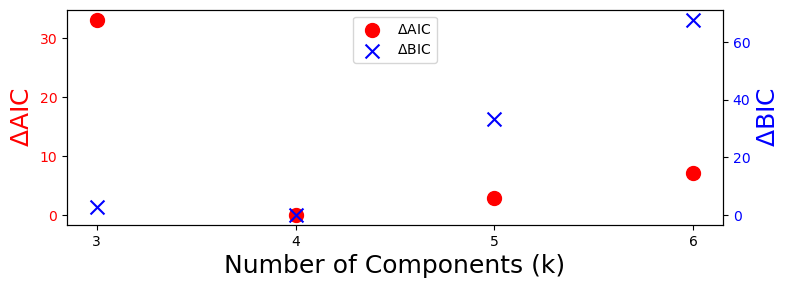

(<Figure size 800x300 with 2 Axes>,
 <Axes: xlabel='Number of Components (k)', ylabel='$\\Delta\\text{AIC}$'>,
 <Axes: ylabel='$\\Delta\\text{BIC}$'>)

In [7]:
# Plotting AIC and BIC

criteria_by_k = {}
n_observations = h_obs.Integral()
for k, result in results.items():
    if k == 2:
        continue
    # print(result)
    best_result_idx = np.argmin([r["nll"] for r in result])
    best_result = result[best_result_idx]
    criteria_by_k[k] = fitting.compute_information_criteria(
        best_result['nll'],
        2 * k - 1,
        n_observations,
    )

plotting.plot_information_criteria(
    criteria_by_k,
        save_as=f"{figures_cache}/dijet_model_selection.pdf" )

In [21]:
# Fitting
n_data = h_obs.Integral()

# Dijet Fit
dijet_model = models.Dijet(x)
fit_result = dijet_model.pdf.fitTo(dijet_data, *fit_options)
print("Dijet Fit Results:")

nll = fit_result.minNll()
n_params = 3
AIC = 2*n_params + 2*nll
BIC = n_params*np.log(n_data) + 2*nll

print(f"Dijet Fit: nll={nll:.2f}, AIC={AIC:.2f}, BIC={BIC:.2f}")
fitting.chi2(
    x,
    h_obs,
    dijet_model,
    min_events=30,
    print_chi2=True,
)

# Exponential Mixture Model Fit
# fit_options.append(ROOT.RooFit.Strategy(2))
k=4
n_params = 2*k - 1
# expmix = models.ExponentialMixtureModel(x, k, data_mean=dijet_data.mean(x))
expmix = models.ExponentialMixtureModel(x, 4, data_mean=1350)
best_fit_pars = results[k][-1]['final_pars']
expmix.set_params(best_fit_pars)

nll = results[k][-1]['nll']
AIC = 2*n_params + 2*nll
BIC = n_params*np.log(n_data) + 2*nll

print(f"Exponential Mixture Model k={k} Fit Results: nll={nll:.2f}, AIC={AIC:.2f}, BIC={BIC:.2f}")
fitting.chi2(
    x,
    h_obs,
    expmix,
    min_events=30,
    print_chi2=True,
)

# Print results
expmix.print()

Dijet Fit Results:
Dijet Fit: nll=186084288.12, AIC=372168582.25, BIC=372168627.76
chi2=95.77, ndf=74, chi2/ndf=1.294, 
Exponential Mixture Model k=4 Fit Results: nll=186084283.99, AIC=372168581.97, BIC=372168688.16
chi2=89.61, ndf=69, chi2/ndf=1.299, 
Model: ExponentialMixture-4
raw_rate_0: 2.134861202110175 + -1.0 1.0
raw_rate_1: 0.8300432617080732 + -1.0 1.0
raw_rate_2: 0.5171394909409159 + -1.0 1.0
raw_rate_3: 1.285988270568433 + -1.0 1.0
raw_weight_0: 0.0 + -1.0 1.0
raw_weight_1: 1.0788560560893563 + -1.0 1.0
raw_weight_2: 0.2915717910323344 + -1.0 1.0
raw_weight_3: 0.8699945101538207 + -1.0 1.0
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) 

[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)


Info in <TCanvas::SaveAs>: ROOT file dijet_fit_comparison.root has been created


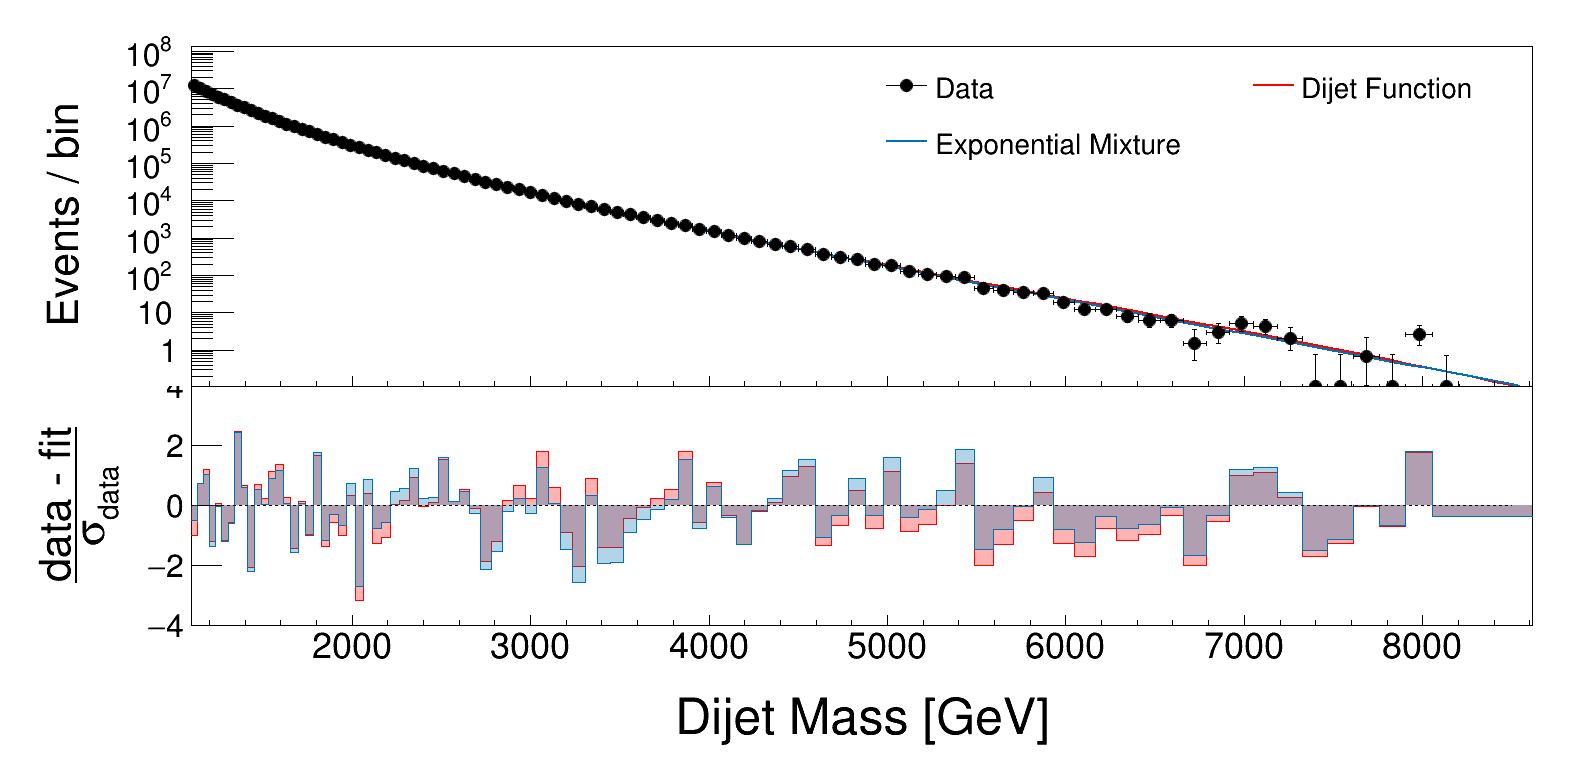

In [24]:
# Plotting
models = [
    # pdf_fit,
    dijet_model.pdf,
    expmix.pdf,
    # gpd_model.pdf,
]
model_labels = [
    # "SW Dijet Fit",
    "Dijet Function",
    f"Exponential Mixture",
    # "f_{GPD}",
    ]
model_colors = [
    ROOT.kRed,
    plotting.default_root_colors[4],
]
model_linestyles = [
    "dashed",
    "solid",
]

c = plotting.plot_fits(
    dijet_data, x, models,
    labels=model_labels,
    colors=model_colors,
    # linestyles=model_linestyles,
    # logx=True,
    # legend_bounds=(0.4, 0.56, 0.95, 0.85),
    plot_range=(x.getMin(), 8500),
    legend_text_size=0.08,
    legend_columns=2,
    # pull_range=(-20,20)
    )

# Save canvas as ROOT file
output_root_file = "dijet_fit_comparison.root"
c.SaveAs(output_root_file)

# CMS

In [ ]:
# Now lets try the CMS result
# https://www.hepdata.net/record/ins1764471
yaml_file = "/project01/ndcms/atownse2/ExponentialMixtureModel/data/dijet_CMS/dijet.yaml"
import ROOT
import yaml
import array

def load_hepdata_to_histogram(yaml_file_path):
    """
    Parses HEPData YAML and returns a ROOT TH1D histogram.
    """
    with open(yaml_file_path, 'r') as f:
        data = yaml.safe_load(f)

    # 1. Extract bin edges from independent_variables
    # We take the 'low' value of the first bin and 'high' values of all bins
    bin_info = data['independent_variables'][0]['values']
    bin_edges = [bin_info[0]['low']]
    for b in bin_info:
        bin_edges.append(b['high'])
    
    # Convert list to a double array for ROOT
    edges_array = array.array('d', bin_edges)
    num_bins = len(bin_edges) - 1

    # 2. Initialize the TH1D
    h_obs = ROOT.TH1D(
        "data",
        "Observed Dijet Events;Dijet mass [GeV];Events",
        num_bins,
        edges_array
    )
    # h_obs.Sumw2()  # Enable storage of sum of squares of weights for error
    h_xs = ROOT.TH1D(
        "cross_section",
        "Dijet Cross-section;Dijet mass [GeV];Cross-section [pb/GeV]",
        num_bins,
        edges_array
    )
    # h_xs.Sumw2()  # Enable storage of sum of squares of weights for

    # 3. Extract Observed Event values
    obs_data = data['dependent_variables'][0]
    values = obs_data['values']
    for i, entry in enumerate(values):
        val = entry['value']
        h_obs.SetBinContent(i + 1, val)
        # print(f"Bin {i+1}: Observed Events = {val}, Edges = [{h_obs.GetBinLowEdge(i+1)}, {h_obs.GetBinLowEdge(i+2)}]")

    # 4. Extract Cross-section values and errors
    # Note: Cross-section is the second dependent variable in your file
    xs_data = data['dependent_variables'][1]
    values = xs_data['values']
    for i, entry in enumerate(values):
        val = entry['value']
        # HEPData often provides asymmetric errors (plus/minus)
        # ROOT TH1 only supports symmetric errors; we take the average or the 'plus' error.
        err_info = entry['errors'][0]['asymerror']
        err_plus = abs(err_info['plus'])
        err_minus = abs(err_info['minus'])
        avg_err = (err_plus + err_minus) / 2.0

        # ROOT bins are 1-indexed (bin 0 is underflow)
        # print(f"Bin {i+1}: Value = {val}, Error = {avg_err}"    )
        h_xs.SetBinContent(i + 1, val)
        h_xs.SetBinError(i + 1, avg_err)
    # hist.Sumw2()  # Ensure errors are stored correctly
    return h_obs, h_xs

# Example usage:
h_obs, h_xs = load_hepdata_to_histogram(yaml_file)

In [ ]:
# Fit the model they use in the dijet paper for comparison
x = ROOT.RooRealVar("x", "x", h_obs.GetXaxis().GetXmin(), h_obs.GetXaxis().GetXmax())
boundaries = [h_obs.GetXaxis().GetBinLowEdge(i) for i in range(1, h_obs.GetXaxis().GetNbins() + 2)]
binning = ROOT.RooBinning(len(boundaries) - 1, array.array('d', boundaries))
x.setBinning(binning)

data = ROOT.RooDataHist("data", "data", ROOT.RooArgList(x), ROOT.RooFit.Import(h_obs))

fit_options = [
    ROOT.RooFit.IntegrateBins(0.001),
    ROOT.RooFit.PrintLevel(-1),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Save()
]

dijet_model = emm.Dijet3(x)
result = dijet_model.pdf.fitTo(data, *fit_options)
_ = chi2(dijet_model.pdf, data)
# print("Fit Result from default initialization:", result.status())

k=3
expmix = emm.ExponentialMixtureModel(x, k, data_mean=data.mean(x))
expmix.pdf.fitTo(data, *fit_options)
_ = chi2(expmix.pdf, data)

emm.plot_fits(
    data, x, [dijet_model.pdf, expmix.pdf],
    model_labels=["Dijet 4 Param Fit", f"EMM k={k} Fit"],
    title="CMS Dijet Spectrum Fit",
    y_min=1e-3,
)

In [ ]:
# Fit the model they use in the dijet paper for comparison
x = ROOT.RooRealVar("x", "x", h_obs.GetXaxis().GetXmin(), h_obs.GetXaxis().GetXmax())
boundaries = [h_obs.GetXaxis().GetBinLowEdge(i) for i in range(1, h_obs.GetXaxis().GetNbins() + 2)]
binning = ROOT.RooBinning(len(boundaries) - 1, array.array('d', boundaries))
x.setBinning(binning)

data = ROOT.RooDataHist("data", "data", ROOT.RooArgList(x), ROOT.RooFit.Import(h_obs))

dijet_model = emm.Dijet3(x)
result = dijet_model.pdf.fitTo(data, ROOT.RooFit.Save(), ROOT.RooFit.IntegrateBins(0.001), ROOT.RooFit.PrintLevel(-1))
print("Fit Result from default initialization:", result.status())

# Lets add a trigger model
mu = ROOT.RooRealVar("mu", "mu", 1250, 1000, 2000)
s = ROOT.RooRealVar("s", "s", 250, 10, 500)

cdf = ROOT.RooFormulaVar(
    "cdf"
    "Gaussian CDF",
    f"0.5*(1 + TMath::Erf(({x.GetName()} - {mu.GetName()})/(sqrt(2)*{s.GetName()})))",
    ROOT.RooArgList(x, mu, s)
)

k=3
expmix = emm.ExponentialMixtureModel(x, k, data_mean=data.mean(x))
expmix.pdf.fitTo(data, ROOT.RooFit.Save(), ROOT.RooFit.IntegrateBins(0.001), ROOT.RooFit.PrintLevel(-1))
print("EMM Fit Result from default initialization:", result.status())
expmix.print()

full_model = ROOT.RooEffProd("full_model", "full_model", expmix.pdf, cdf)
full_model.fitTo(data, ROOT.RooFit.IntegrateBins(0.001), ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Save())

emm.plot_fits(
    data, x,
    [dijet_model.pdf, full_model],
    model_labels=["Dijet 4 Param Fit", f"EMM k={k} Fit with Trigger"],
    title="CMS Dijet Spectrum Fit",
    y_min=1e-5,
    # logx=True,
    # colors=[ROOT.kGreen],
    # binning=binning,
    # plot_range=(1100, 1500),
)
# model.print()

In [ ]:
print(f"mu: {mu.getValV()}, s: {s.getValV()}")

In [ ]:
# Generate a dataset from the Dijet model and fit with EMM
# toy_data = dijet_model.pdf.generate(ROOT.RooArgSet(x), int(data.sumEntries()))
toy_data = dijet_model.pdf.generate(ROOT.RooArgSet(x), int(1_000_000))

# Set binning for x
boundaries = [h_obs.GetXaxis().GetBinLowEdge(i) for i in range(1, h_obs.GetXaxis().GetNbins() + 2)]
binning = ROOT.RooBinning(len(boundaries) - 1, array.array('d', boundaries))
x.setBinning(binning)

toy_model = emm.Dijet3(x)
toy_result = toy_model.pdf.fitTo(toy_data, ROOT.RooFit.Save())
print("Toy Dijet Fit Result from default initialization:", toy_result.status())

emm_model = emm.ExponentialMixtureModel(x, 3, data_mean=data.mean(x))
emm_result = emm_model.pdf.fitTo(toy_data, ROOT.RooFit.Save())
print("EMM Fit Result from default initialization:", emm_result.status())

emm.plot_fits(
    toy_data,
    x, [toy_model.pdf, emm_model.pdf],
    model_labels=["Toy Dijet 4 Param Fit", "EMM Fit"],
    # colors=[ROOT.kGreen],
    # binning=binning,
    # plot_range=(1100, 1500),
)
toy_model.print()

In [ ]:
# Do it binned now
toy_data = dijet_model.pdf.generate(ROOT.RooArgSet(x), int(10_000_000))
binned_toy_data = ROOT.RooDataHist("binned_toy_data", "binned_toy_data", ROOT.RooArgList(x), toy_data)

toy_model = emm.Dijet3(x)
toy_result = toy_model.pdf.fitTo(
    binned_toy_data,
    ROOT.RooFit.Save(),
    ROOT.RooFit.IntegrateBins(0.0001),
    ROOT.RooFit.PrintLevel(-1),
    ROOT.RooFit.Offset(True))
print("Toy Dijet Fit Result from default initialization:", toy_result.status())

emm_model = emm.ExponentialMixtureModel(x, 3, data_mean=data.mean(x))
emm_result = emm_model.pdf.fitTo(
    binned_toy_data,
    ROOT.RooFit.Save(),
    ROOT.RooFit.IntegrateBins(0.0001),
    ROOT.RooFit.PrintLevel(-1),
    ROOT.RooFit.Offset(True))
print("EMM Fit Result from default initialization:", emm_result.status())

emm.plot_fits(
    binned_toy_data,
    x, [toy_model.pdf, emm_model.pdf],
    model_labels=["Toy Dijet 4 Param Fit", "EMM Fit"],
    # colors=[ROOT.kGreen],
    # binning=binning,
    # plot_range=(1100, 1500),
)
toy_model.print()